In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris, load_digits
from sklearn.metrics import accuracy_score, confusion_matrix

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time

## Random Forest (Iris dataset)

In [2]:
from random_forests import DecisionTree, RandomForest

# Dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
ma_foret = RandomForest()
ma_foret.fit(X_train, y_train)

# Prédictions
y_pred = ma_foret.predict(X_test)

# Accuracy
precision = np.sum(y_pred == y_test) / len(y_test)
print(f"Précision de ma forêt : {precision * 100:.2f}%")

Précision de ma forêt : 100.00%


## KMeans (Iris dataset)

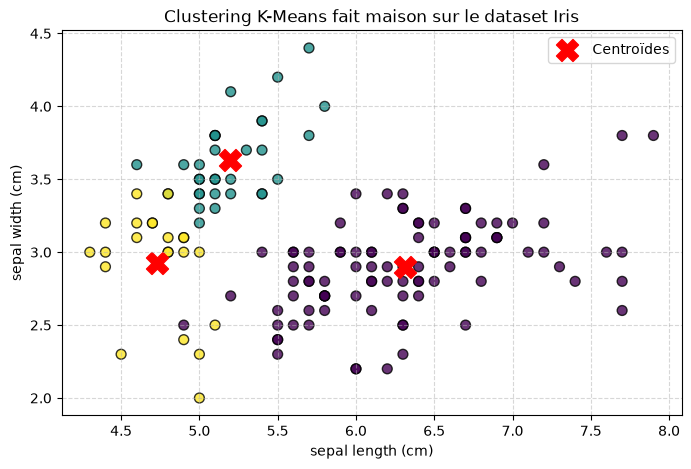

In [3]:
from kmeans import KMeans

iris = load_iris()

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X)

# Visualiser sur les 2 premières variables (Sepal length vs Sepal width)
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=50, edgecolors="k", alpha=0.8)

# Afficher les centroïdes calculés par le modèle (sur les 2 premières dimensions)
plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    c="red",
    marker="X",
    s=250,
    label="Centroïdes",
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Clustering K-Means fait maison sur le dataset Iris")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Neural Network (MLP)

#### Test on the MNIST dataset

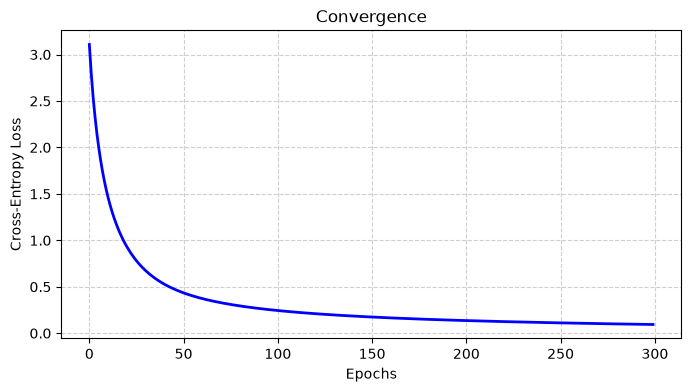

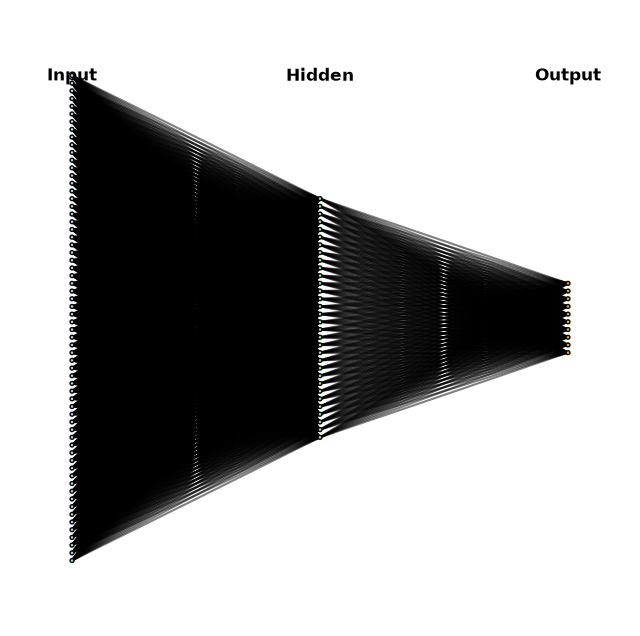

In [15]:
from sklearn.preprocessing import StandardScaler
from neural_network import Neural_Network

# Chargement des données (Images 8x8 pixels = 64 variables, 10 classes)
digits = load_digits()
X, y = digits.data, digits.target

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardisation Z-score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-Hot Encoding pour l'entraînement
n_classes = 10
y_train_ohe = np.eye(n_classes)[y_train]

# Instanciation du modèle (64 pixels en entrée, 32 neurones cachés, 10 classes en sortie)
mon_mlp = Neural_Network(
    input_size = X_train.shape[1], 
    hidden_size = 32, 
    output_size = n_classes, 
    learning_rate = 0.1, 
    epochs = 300
)

# Entraînement du modèle
loss_history = mon_mlp.train(X_train_scaled, y_train_ohe)

# Graphique de la convergence (Cross-Entropy)
plt.figure(figsize=(8, 4))
plt.plot(loss_history, lw=2, color="blue")
plt.title("Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Affichage de l'architecture du réseau
# 64 neurones en entrée créent un visuel très dense
mon_mlp.display()

### Benchmark vs sklearn.MLPClassifier

RÉSULTATS DU BENCHMARK :
-----------------------------------------------------------------
Modèle          | Précision | Temps Entraînement | Temps Inférence
-----------------------------------------------------------------
Mon MLP         | 95.6%     | 0.2807s           | 0.00018s
Scikit-Learn    | 97.8%     | 0.1560s           | 0.00042s


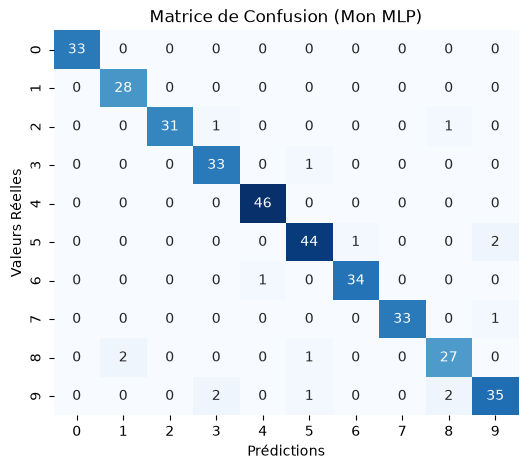

In [16]:
from sklearn.neural_network import MLPClassifier

# Temps d'entraînement
# (On ré-initialise un modèle neuf pour un chrono équitable)
mon_mlp = Neural_Network(input_size=X_train.shape[1], hidden_size=32, output_size=10, learning_rate=0.1, epochs=300)
sklearn_mlp = MLPClassifier(hidden_layer_sizes=(32,), learning_rate_init=0.1, max_iter=300, random_state=42, solver='sgd')

t0 = time.time()
mon_mlp.train(X_train_scaled, y_train_ohe)
time_train_mine = time.time() - t0

t0 = time.time()
sklearn_mlp.fit(X_train_scaled, y_train)
time_train_sk = time.time() - t0

# Temps d'inférence (Prédiction)
t0 = time.time()
y_pred_mine = mon_mlp.predict(X_test_scaled)
time_infer_mine = time.time() - t0

t0 = time.time()
y_pred_sk = sklearn_mlp.predict(X_test_scaled)
time_infer_sk = time.time() - t0

# Précision
acc_mine = accuracy_score(y_test, y_pred_mine)
acc_sk = accuracy_score(y_test, y_pred_sk)

# --- Résultats ---
print("RÉSULTATS DU BENCHMARK :")
print("-" * 65)
print(f"Modèle          | Précision | Temps Entraînement | Temps Inférence")
print("-" * 65)
print(f"Mon MLP         | {acc_mine*100:.1f}%     | {time_train_mine:.4f}s           | {time_infer_mine:.5f}s")
print(f"Scikit-Learn    | {acc_sk*100:.1f}%     | {time_train_sk:.4f}s           | {time_infer_sk:.5f}s")

# --- Matrice de confusion pour ton modèle ---
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_mine), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matrice de Confusion (Mon MLP)")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.show()